In [37]:
# Import Necessary Libraries
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# Handling Imbalanced Dataset
from imblearn.over_sampling import SMOTE

# Model Saving
import joblib

# SHAP
import shap

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [38]:
# Load Dataset
df = pd.read_csv("credit_risk_dataset.csv")

# Display first 5 rows
print(df.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [39]:
# Understand the dataset

# Shape of dataset
print(df.shape)

# Dataset info
print(df.info())

# Missing values
print(df.isnull().sum())

# Statistical Summary
print(df.describe())

(32581, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None
person_age    

In [40]:
# Data cleaning (Handle Missing Values)

# Fill missing employment length
df['person_emp_length'].fillna(
    df['person_emp_length'].median(),
    inplace=True
)

# Fill missing interest rate
df['loan_int_rate'].fillna(
    df['loan_int_rate'].mean(),
    inplace=True
)

In [41]:
# Encode Categorical Features
categorical_columns = [
    'person_home_ownership',
    'loan_intent',
    'cb_person_default_on_file'
]

In [42]:
# Apply Label Encoding
encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col]=le.fit_transform(df[col])
    encoders[col]=le

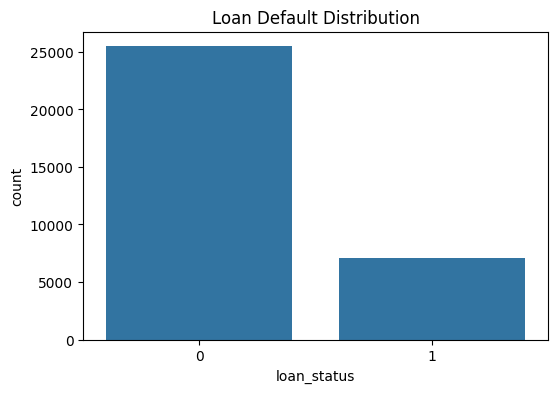

In [43]:
# Exploratory Data Analysis
# Loan Default Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x='loan_status',
    data=df
)
plt.title("Loan Default Distribution")
plt.show()

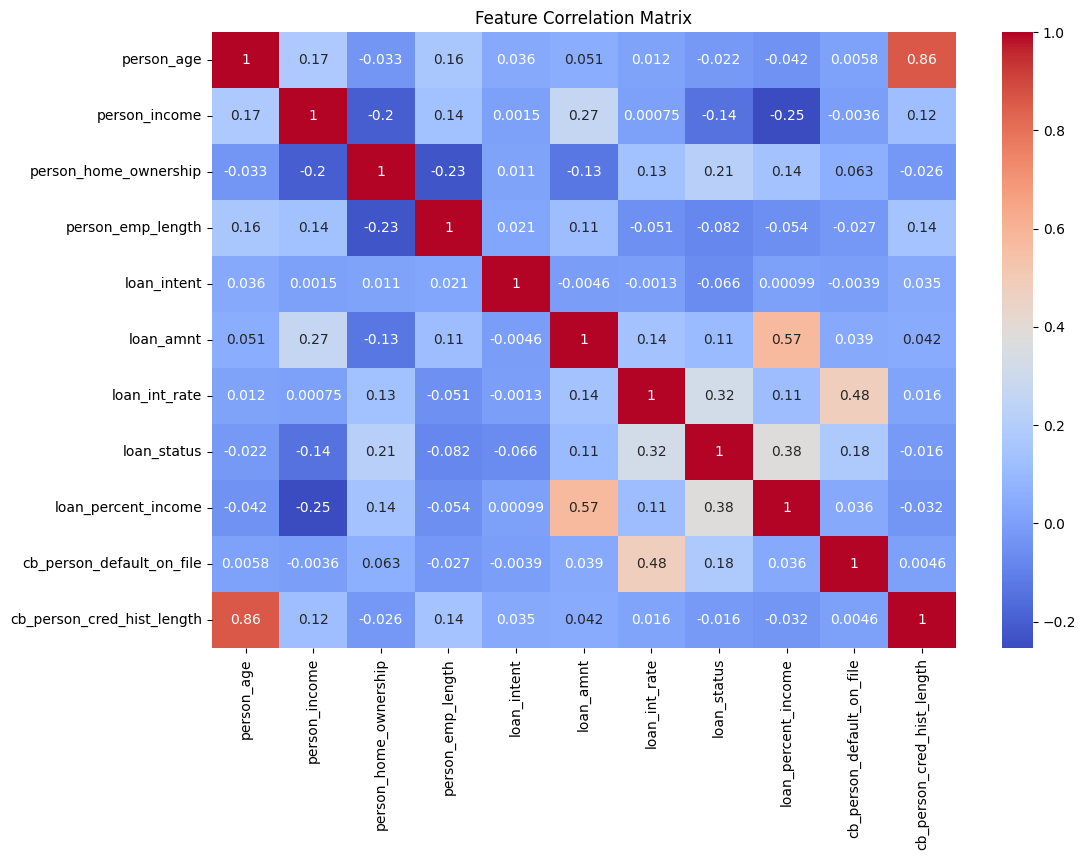

In [44]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

In [45]:
# Feature and Target Separation
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [46]:
# Encode ALL object columns first
from sklearn.preprocessing import LabelEncoder

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col])

In [47]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [49]:
# Handle imbalanced data using SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [50]:
# Train multiple models
models = {
    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Random Forest":
    RandomForestClassifier(random_state=42),

    "XG Boost":
    XGBClassifier(
        eval_metrics = 'logloss',
        Random_state=42
    )
}

In [51]:
# Model Training and Evaluation
results = []

for name, model in models.items():

    # Train model
    model.fit(X_train_smote, y_train_smote)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Probability
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    print("\n")
    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy:", accuracy)

    print("ROC-AUC:", auc)

    print(classification_report(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "ROC-AUC": auc
    })



Logistic Regression
Accuracy: 0.7850237839496701
ROC-AUC: 0.8531928519866558
              precision    recall  f1-score   support

           0       0.93      0.79      0.85      5095
           1       0.50      0.77      0.61      1422

    accuracy                           0.79      6517
   macro avg       0.72      0.78      0.73      6517
weighted avg       0.83      0.79      0.80      6517



Random Forest
Accuracy: 0.927267147460488
ROC-AUC: 0.9278844017120561
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      5095
           1       0.93      0.72      0.81      1422

    accuracy                           0.93      6517
   macro avg       0.93      0.85      0.88      6517
weighted avg       0.93      0.93      0.92      6517



XG Boost
Accuracy: 0.9343256099432254
ROC-AUC: 0.944842645156927
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       

In [52]:
# Select the best model
best_model = models["XG Boost"]

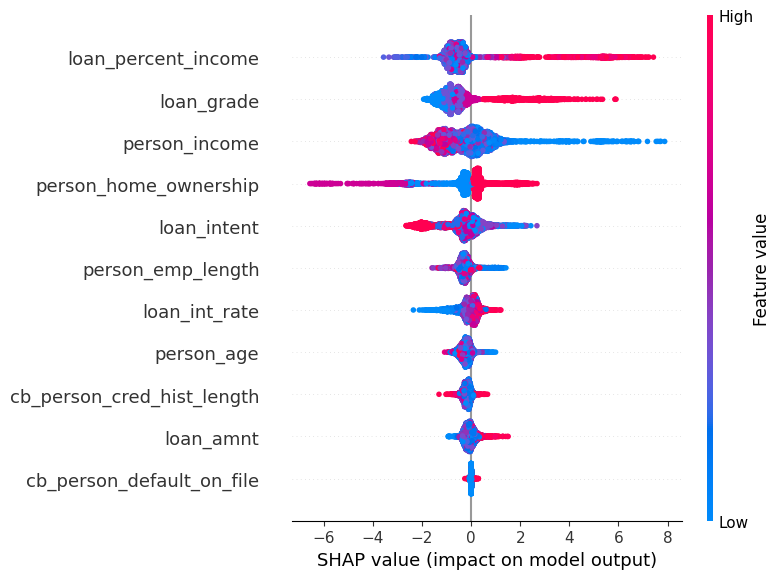

In [53]:
# Generate shap values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

# Shap Summary Plot
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

In [56]:
import os

os.makedirs("models", exist_ok=True)

In [57]:
# Save the model and scaler
joblib.dump(best_model, "models/model.pkl")

joblib.dump(scaler, "models/scaler.pkl")

joblib.dump(encoders, "models/label_encoders.pkl")

['models/label_encoders.pkl']